Explainable Transformer Based Framework for Early Detection of Mental Health Disorders from Social Media Text

---

### imports and paths

In [ ]:
import pickle
import numpy as np
import pandas as pd
import scipy.sparse as sp
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.feature_extraction.text import TfidfVectorizer

SPLITS  = Path('..') / 'datasets' / 'processed' / 'splits'
TFIDF   = Path('..') / 'datasets' / 'processed' / 'tfidf'
TFIDF.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({'figure.dpi': 120, 'axes.spines.top': False,
                     'axes.spines.right': False})
print('paths configured')

---

### load splits

In [2]:
train = pd.read_csv(SPLITS / 'train.csv')
val   = pd.read_csv(SPLITS / 'val.csv')
test  = pd.read_csv(SPLITS / 'test.csv')

X_train = train['clean_text'].fillna('').astype(str).tolist()
X_val   = val['clean_text'].fillna('').astype(str).tolist()
X_test  = test['clean_text'].fillna('').astype(str).tolist()

y_train = train['label_encoded'].values
y_val   = val['label_encoded'].values
y_test  = test['label_encoded'].values

print(f'train  : {len(X_train):,}')
print(f'val    : {len(X_val):,}')
print(f'test   : {len(X_test):,}')

train  : 33,159
val    : 7,106
test   : 7,106


---

### fit tfidf vectorizer

In [3]:
# fit on training data only — prevents data leakage
tfidf = TfidfVectorizer(
    max_features=50_000,
    ngram_range=(1, 2),
    sublinear_tf=True,
    min_df=2,
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_val_tfidf   = tfidf.transform(X_val)
X_test_tfidf  = tfidf.transform(X_test)

print(f'vocabulary size : {len(tfidf.vocabulary_):,}')
print(f'train matrix    : {X_train_tfidf.shape}')
print(f'val matrix      : {X_val_tfidf.shape}')
print(f'test matrix     : {X_test_tfidf.shape}')
print(f'sparsity (train): {1 - X_train_tfidf.nnz / (X_train_tfidf.shape[0] * X_train_tfidf.shape[1]):.4f}')

vocabulary size : 50,000
train matrix    : (33159, 50000)
val matrix      : (7106, 50000)
test matrix     : (7106, 50000)
sparsity (train): 0.9988


---

### top features per class

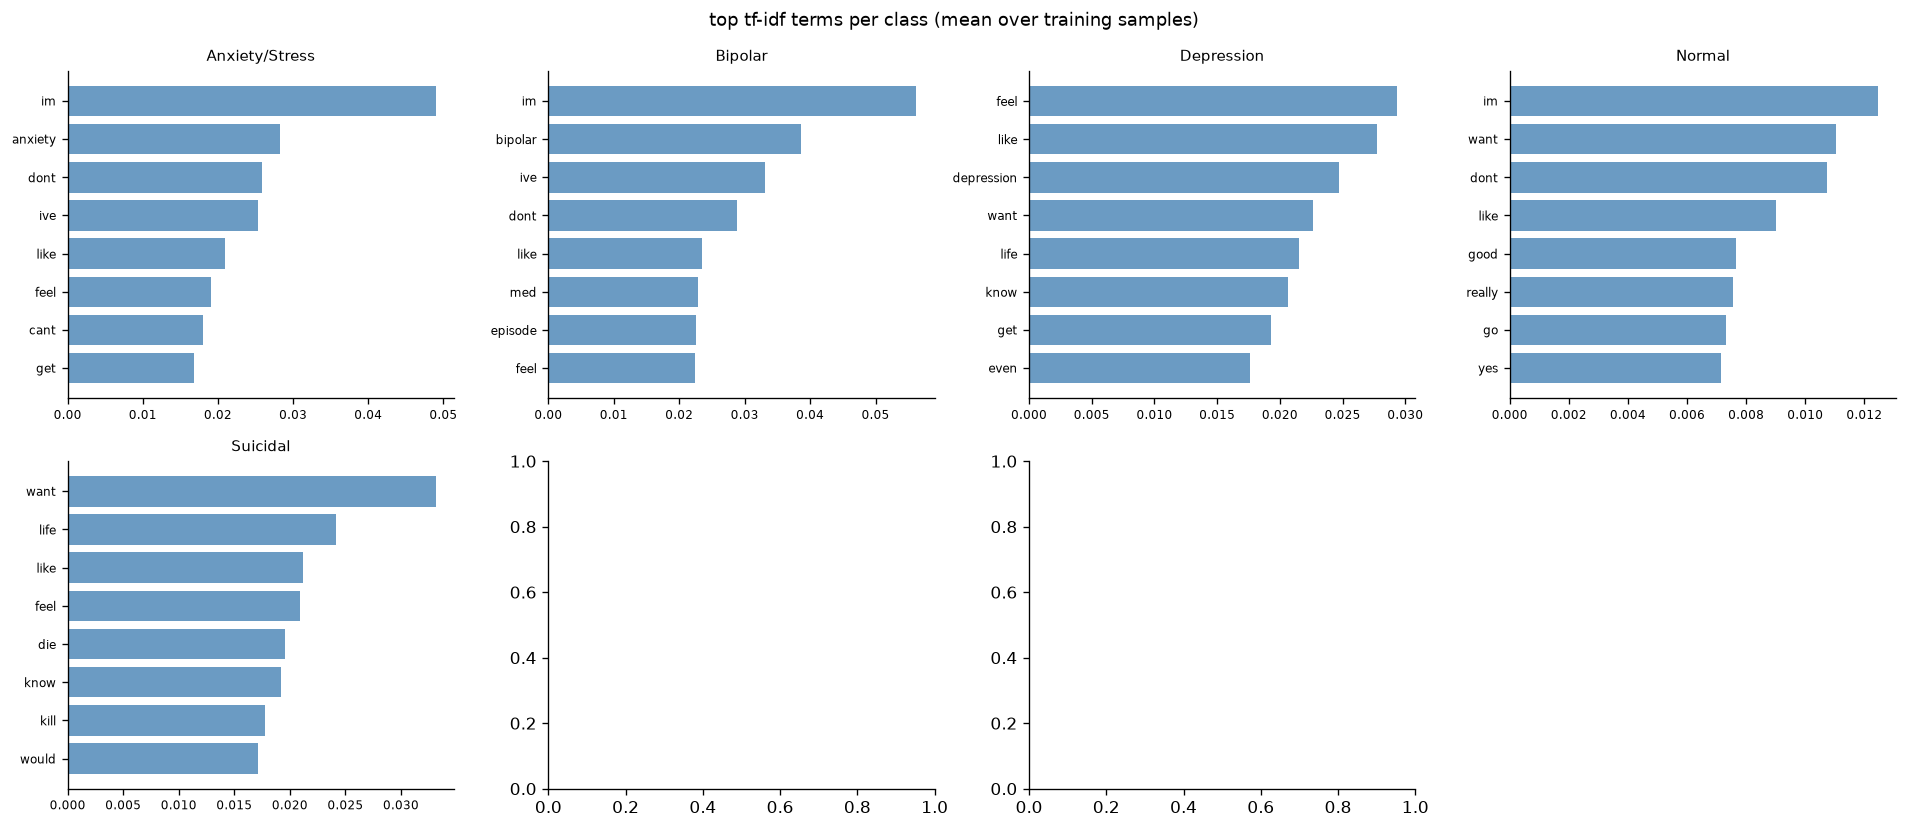

In [4]:
import pickle
with open(SPLITS / 'label_encoder.pkl', 'rb') as fh:
    le = pickle.load(fh)

feature_names = np.array(tfidf.get_feature_names_out())
TOP_N = 8

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()

for idx, cls in enumerate(le.classes_):
    mask = y_train == idx
    class_matrix = X_train_tfidf[mask]
    mean_tfidf = np.asarray(class_matrix.mean(axis=0)).flatten()
    top_idx = mean_tfidf.argsort()[-TOP_N:][::-1]
    top_words = feature_names[top_idx]
    top_vals  = mean_tfidf[top_idx]
    axes[idx].barh(top_words[::-1], top_vals[::-1], color='steelblue', alpha=0.8)
    axes[idx].set_title(cls, fontsize=9)
    axes[idx].tick_params(labelsize=7)

# hide unused subplot
axes[-1].set_visible(False)
fig.suptitle('top tf-idf terms per class (mean over training samples)', fontsize=11)
plt.tight_layout()
plt.show()

---

### save artifacts

In [ ]:
# save vectorizer — fitted on training data only
with open(TFIDF / 'tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf, f)

# save sparse feature matrices for each split
sp.save_npz(str(TFIDF / 'X_train.npz'), X_train_tfidf)
sp.save_npz(str(TFIDF / 'X_val.npz'),   X_val_tfidf)
sp.save_npz(str(TFIDF / 'X_test.npz'),  X_test_tfidf)

# save encoded labels
np.save(str(TFIDF / 'y_train.npy'), y_train)
np.save(str(TFIDF / 'y_val.npy'),   y_val)
np.save(str(TFIDF / 'y_test.npy'),  y_test)

print('artifacts saved:')
for f in sorted(TFIDF.iterdir()):
    print(f'  {f.name:<30} {f.stat().st_size/1024:>8.1f} KB')